In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import re

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv(
    'twitter_training.csv',
    header=None
)

df.columns = [
    'Tweet_ID',
    'Entity',
    'Sentiment',
    'Tweet'
]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

df.info()

Dataset Shape:
(74682, 4)

Columns:
Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [5]:
df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


In [6]:
df.dropna(inplace=True)

print(df.shape)

(73996, 4)


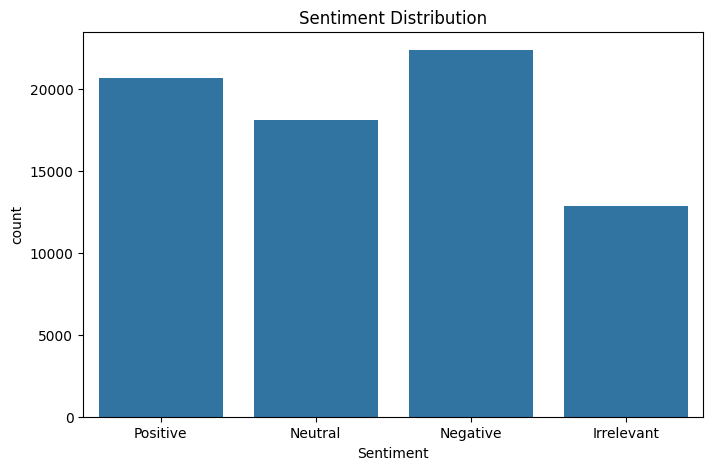

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

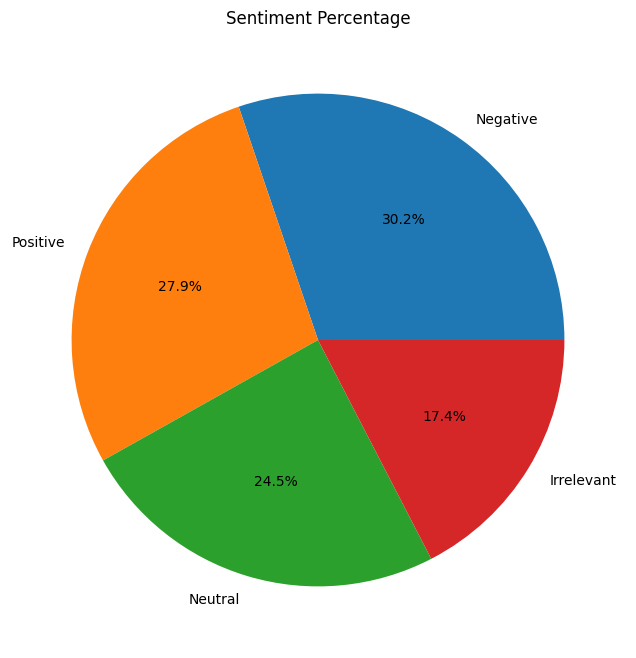

In [8]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Percentage")

plt.show()

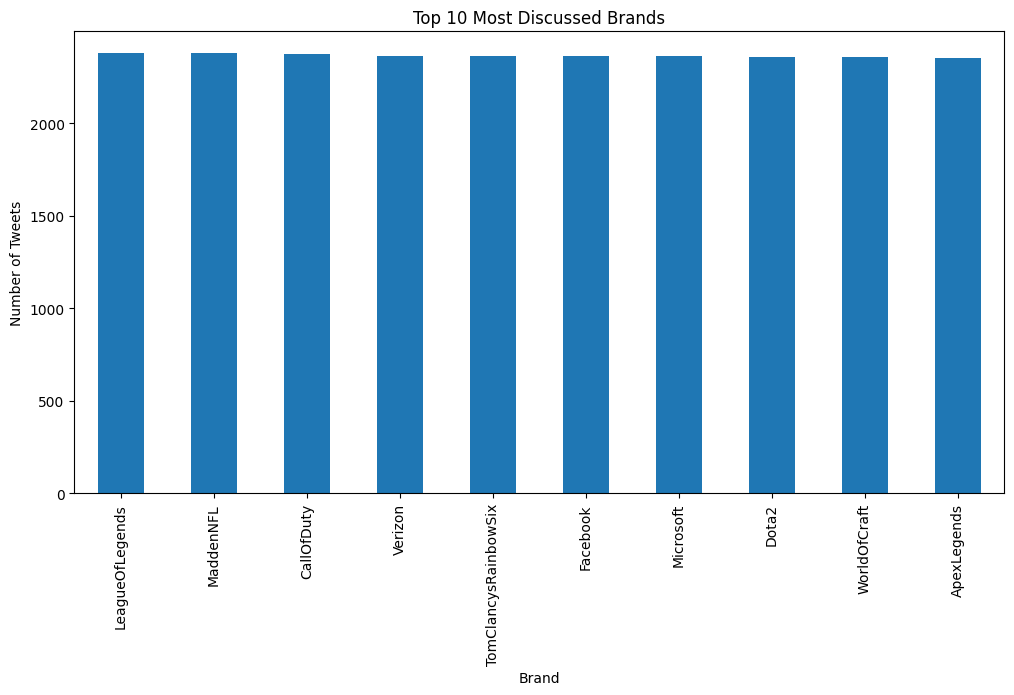

In [9]:
plt.figure(figsize=(12,6))

df['Entity'].value_counts().head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Most Discussed Brands"
)

plt.xlabel("Brand")

plt.ylabel("Number of Tweets")

plt.show()

In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [12]:
nltk.download('punkt_tab')
df['Clean_Tweet'] = df['Tweet'].apply(
    clean_text
)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Tweet_ID,Entity,Sentiment,Tweet,Clean_Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming borders kill
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderlands murder
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderlands murder


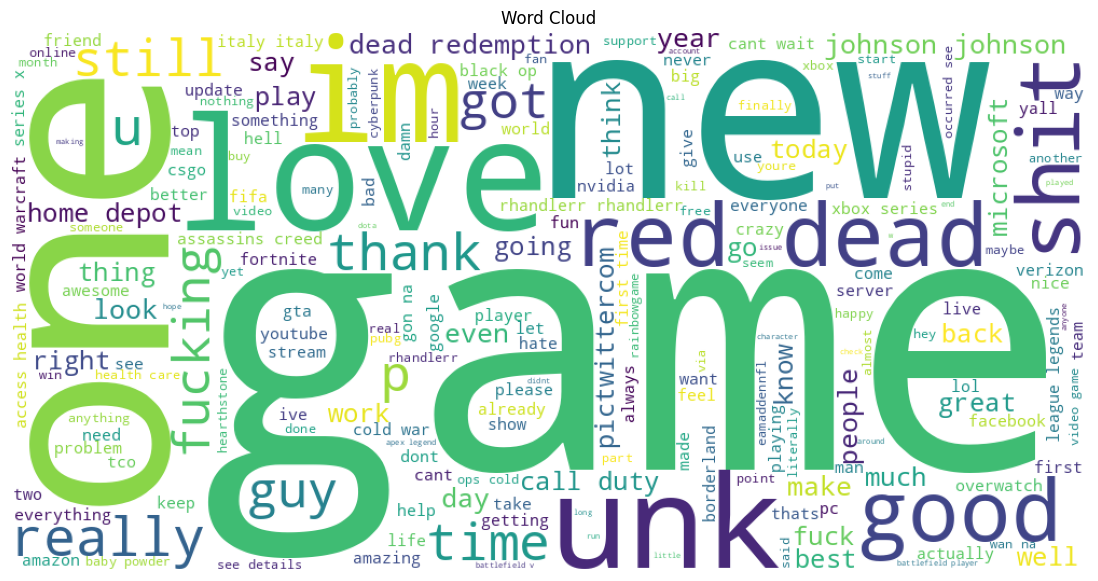

In [13]:
text = " ".join(
    df['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

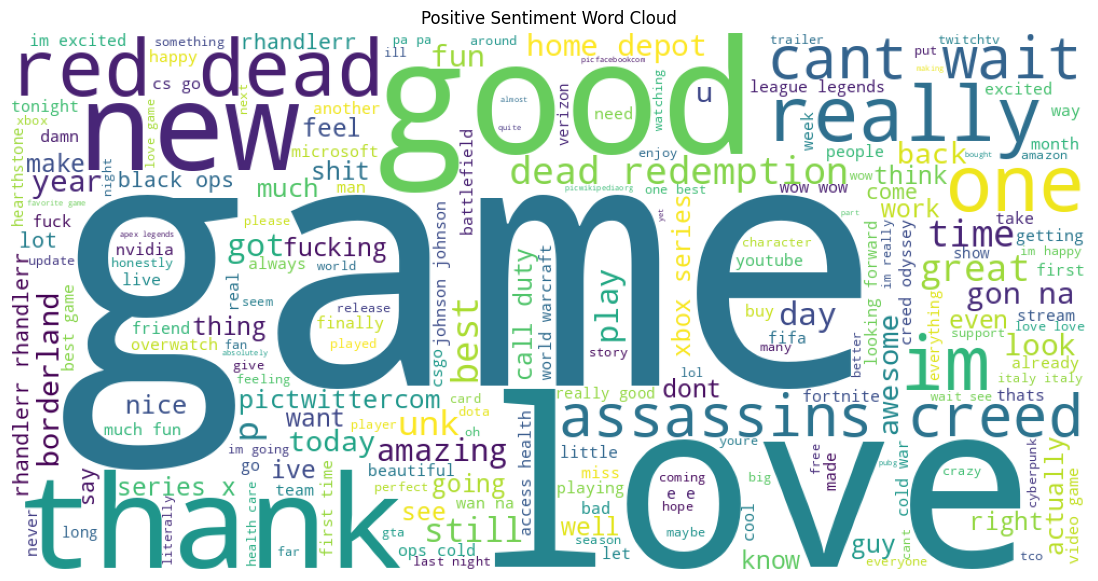

In [14]:
positive_text = " ".join(
    df[df['Sentiment']=='Positive']['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Positive Sentiment Word Cloud"
)

plt.show()

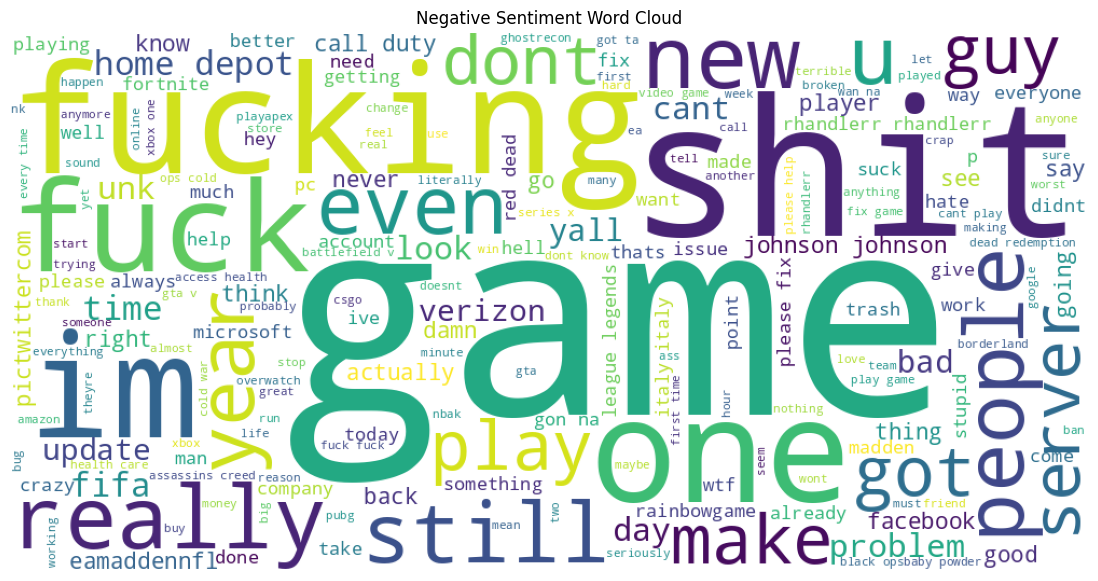

In [15]:
negative_text = " ".join(
    df[df['Sentiment']=='Negative']['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Negative Sentiment Word Cloud"
)

plt.show()

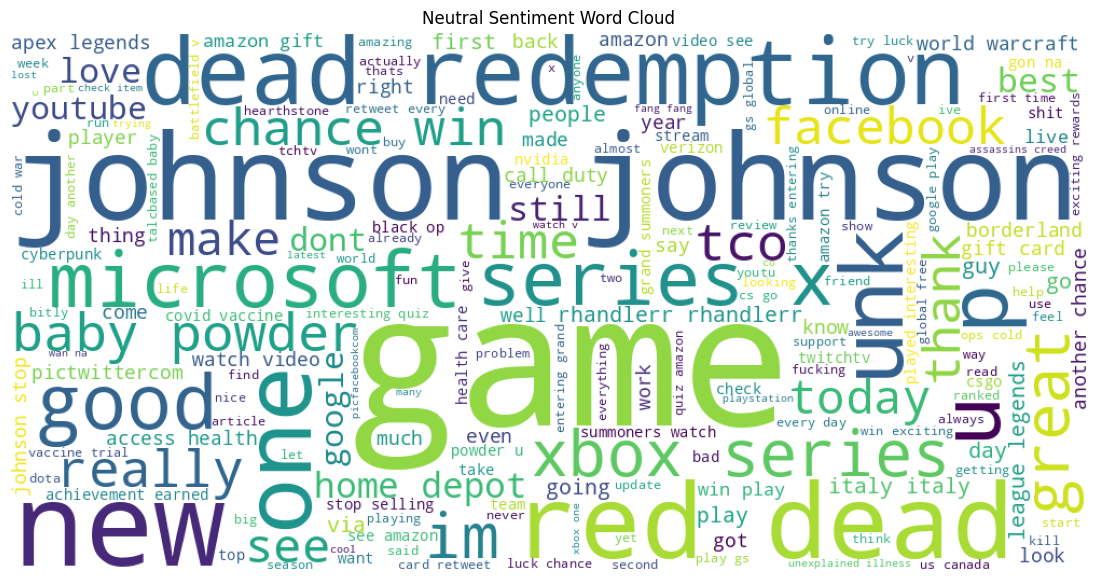

In [16]:
neutral_text = " ".join(
    df[df['Sentiment']=='Neutral']['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Neutral Sentiment Word Cloud"
)

plt.show()

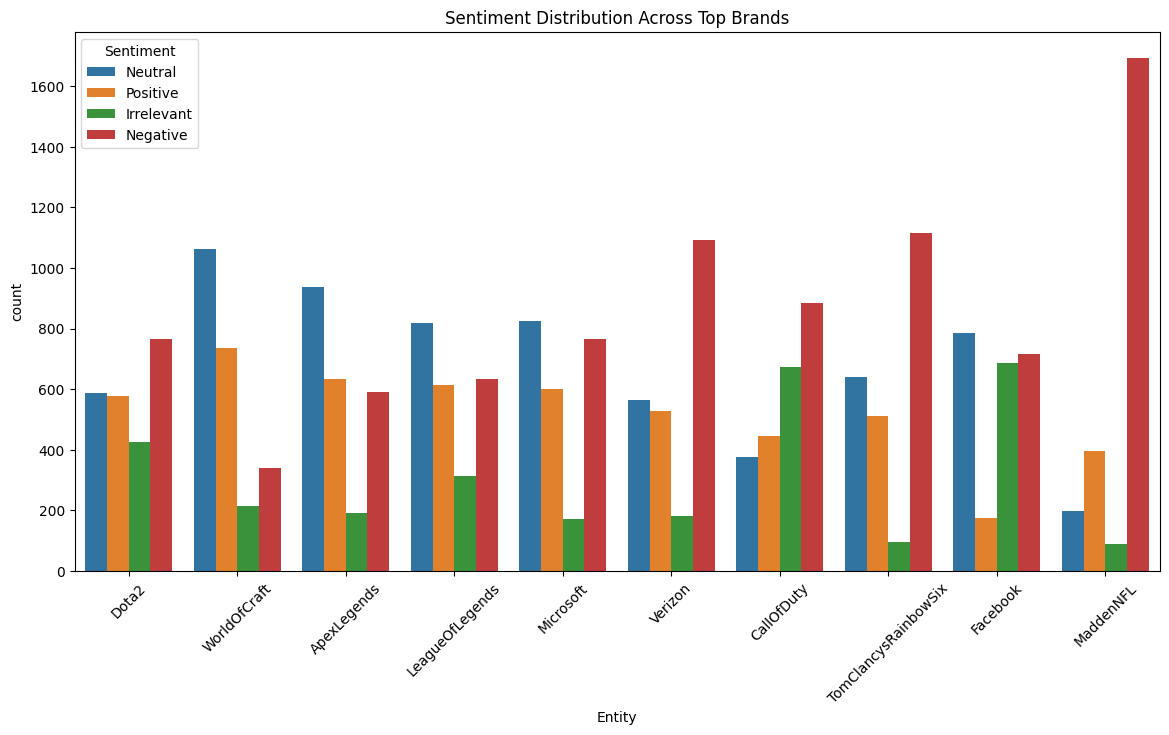

In [17]:
top_brands = df['Entity'].value_counts().head(10).index

brand_df = df[
    df['Entity'].isin(top_brands)
]

plt.figure(figsize=(14,7))

sns.countplot(
    data=brand_df,
    x='Entity',
    hue='Sentiment'
)

plt.xticks(rotation=45)

plt.title(
    "Sentiment Distribution Across Top Brands"
)

plt.show()

In [18]:
sentiment_table = pd.crosstab(
    df['Entity'],
    df['Sentiment']
)

sentiment_table.head()

Sentiment,Irrelevant,Negative,Neutral,Positive
Entity,,,,
Amazon,186,575,1207,308
ApexLegends,192,591,936,634
AssassinsCreed,264,375,156,1439
Battlefield,915,464,351,586
Borderlands,240,426,597,1017


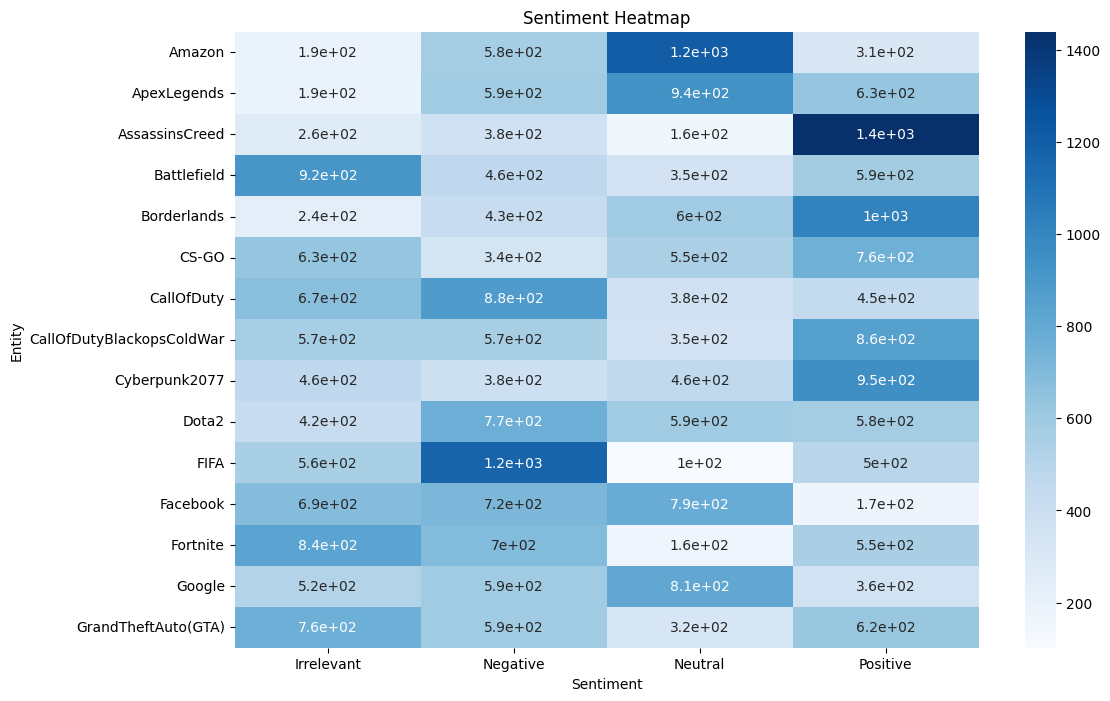

In [19]:
top_sentiment = sentiment_table.head(15)

plt.figure(figsize=(12,8))

sns.heatmap(
    top_sentiment,
    annot=True,
    cmap='Blues'
)

plt.title(
    "Sentiment Heatmap"
)

plt.show()

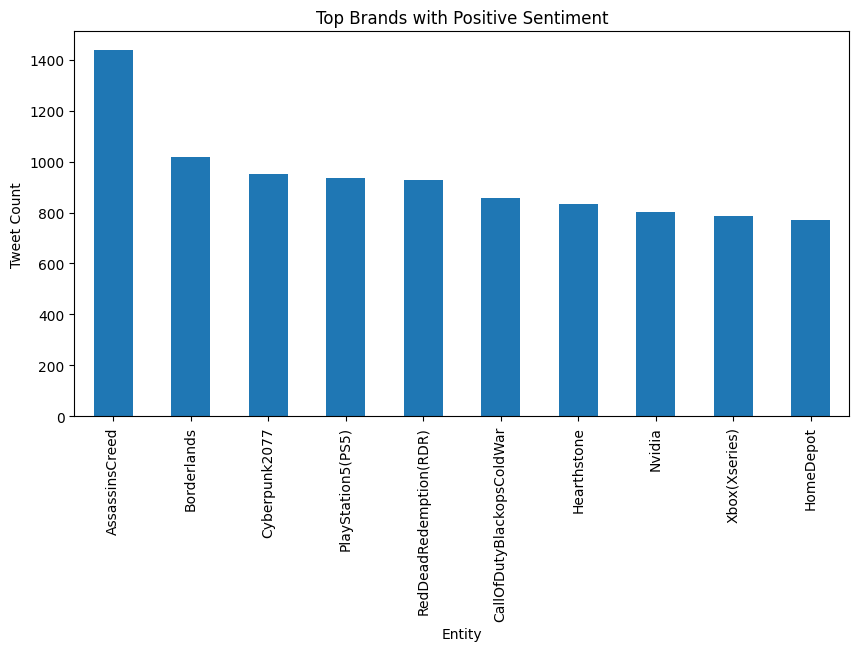

In [20]:
positive_counts = df[
    df['Sentiment']=='Positive'
]['Entity'].value_counts().head(10)

plt.figure(figsize=(10,5))

positive_counts.plot(
    kind='bar'
)

plt.title(
    "Top Brands with Positive Sentiment"
)

plt.ylabel("Tweet Count")

plt.show()

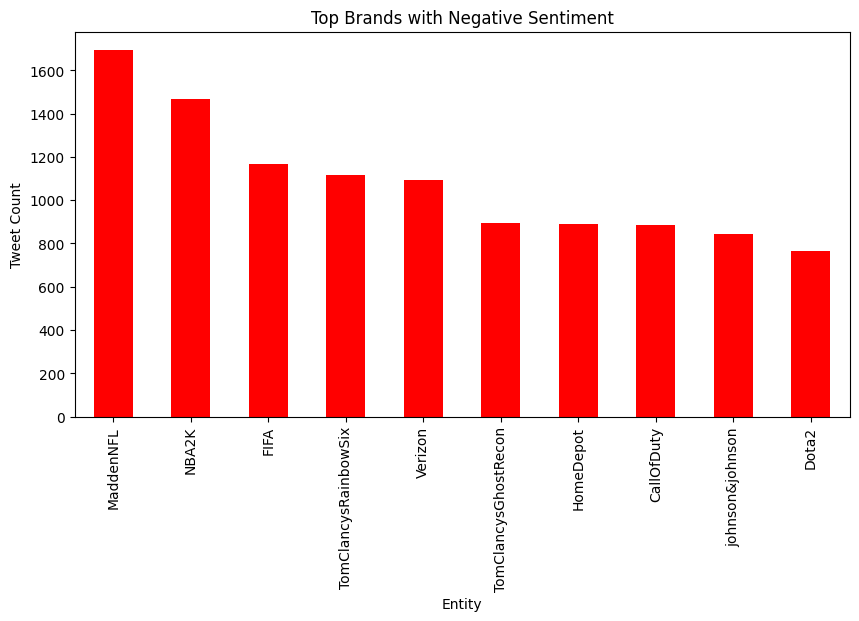

In [21]:
negative_counts = df[
    df['Sentiment']=='Negative'
]['Entity'].value_counts().head(10)

plt.figure(figsize=(10,5))

negative_counts.plot(
    kind='bar',
    color='red'
)

plt.title(
    "Top Brands with Negative Sentiment"
)

plt.ylabel("Tweet Count")

plt.show()

In [22]:
sentiment_percentage = (
    df['Sentiment']
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentage)

Sentiment
Negative      30.215147
Positive      27.913671
Neutral       24.471593
Irrelevant    17.399589
Name: proportion, dtype: float64


In [23]:
df.to_csv(
    'cleaned_twitter_sentiment.csv',
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

Cleaned dataset saved successfully.


In [24]:
print("""
KEY INSIGHTS

1. Sentiment distribution reveals overall public opinion.

2. Positive, Negative and Neutral sentiments vary across brands.

3. Certain brands receive significantly more attention than others.

4. Word clouds highlight frequently discussed topics.

5. Sentiment analysis helps understand customer perception and market trends.

TASK 04 COMPLETED SUCCESSFULLY.
""")


KEY INSIGHTS

1. Sentiment distribution reveals overall public opinion.

2. Positive, Negative and Neutral sentiments vary across brands.

3. Certain brands receive significantly more attention than others.

4. Word clouds highlight frequently discussed topics.

5. Sentiment analysis helps understand customer perception and market trends.

TASK 04 COMPLETED SUCCESSFULLY.

